In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


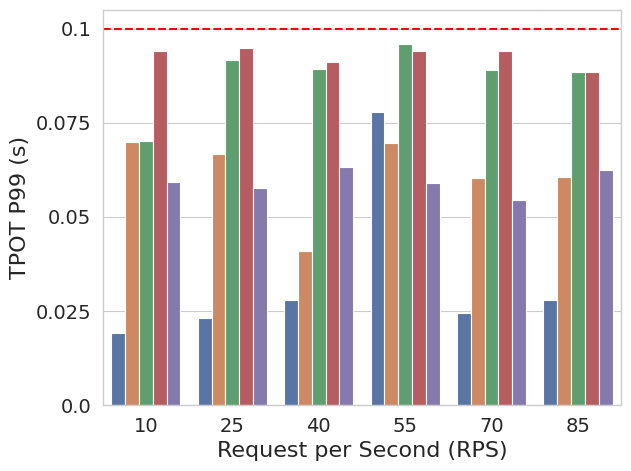

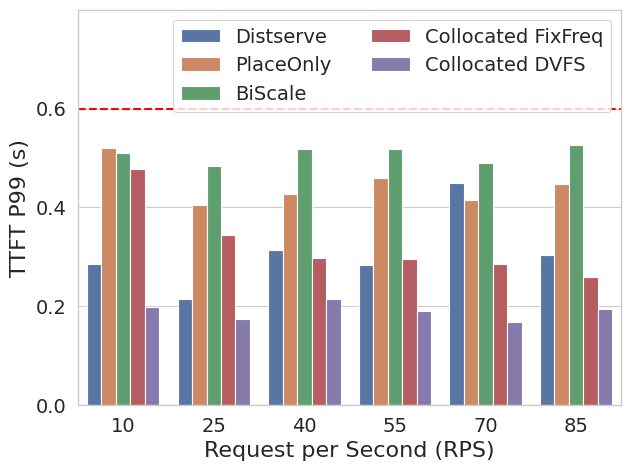

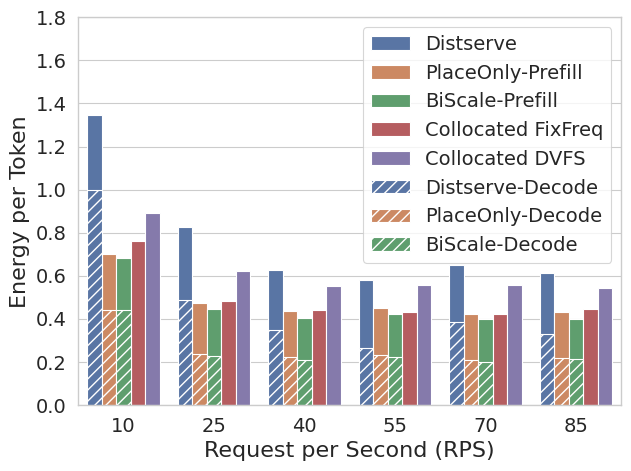

In [ ]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/oracle_67_percent/profiler_logs_0_March29_oracle_fix/metrics.csv"
df_results = pd.read_csv(path)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_2_node0': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_3_node0': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_4_node0': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_5_node0': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_6_node0': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_7_node0': 'Distserve 10',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_2_node0': 'PlaceOnly 85',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_3_node0': 'PlaceOnly 70',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_4_node0': 'PlaceOnly 55',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_5_node0': 'PlaceOnly 40',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_6_node0': 'PlaceOnly 25',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_7_node0': 'PlaceOnly 10',
    'OURS_R5_JAN3_REAL_P67_ORACLE_2_node0': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P67_ORACLE_3_node0': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P67_ORACLE_4_node0': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P67_ORACLE_5_node0': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P67_ORACLE_6_node0': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P67_ORACLE_7_node0': 'BiScale 10',

}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale', 'Collocated FixFreq', 'Collocated DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16)
ax.set_ylabel('TPOT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.105)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=14)
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14)
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/sythetic_trace_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16)
ax.set_ylabel('TTFT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.8)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=14)
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14)
ax.legend(title="", fontsize=14, ncol=2)
plt.tight_layout()
plt.savefig("figs/sythetic_trace_ttft.pdf", format="pdf")

#################### Energy per token ####################
filtered_handles = []
filtered_labels = []

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

df_results_de = df_results[df_results['decode_energy_per_token'].notnull() & df_results['decode_energy_per_token'] > 0]
ax2 = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results_de, 
    dodge=True,
    hatch='///',
)
# Build custom legend
handles, labels = ax.get_legend_handles_labels()
handles = handles[:-2]
labels = labels[:-2]
labels = ['Distserve',
        'PlaceOnly-Prefill',
        'BiScale-Prefill',
        'Collocated FixFreq',
        'Collocated DVFS',
        'Distserve-Decode',
        'PlaceOnly-Decode',
        'BiScale-Decode']

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16)
ax.set_ylabel('Energy per Token', fontsize=16)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['10', '25', '40', '55', '70', '85'], fontsize=14)
ax.set_ylim(0, 1.8)
ax.tick_params(axis='y', labelsize=14)
ax.legend(handles, labels, title="", fontsize=14, ncol=1)
plt.tight_layout()
plt.savefig("figs/sythetic_trace_energy_per_token.pdf", format="pdf")

In [96]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_M'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'PlaceOnly')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results[['expr_dir', 'energy_per_token', 'energy_norm_D', 'energy_norm_M']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_token,energy_norm_D,energy_norm_M
35,PlaceOnly 85,0.430315,29.867673,0.000000
56,PlaceOnly 70,0.424485,34.780279,0.000000
76,PlaceOnly 55,0.450941,22.167351,0.000000
92,PlaceOnly 40,0.438330,30.018458,0.000000
103,PlaceOnly 25,0.472836,42.798126,0.000000
112,PlaceOnly 10,0.701316,47.865604,0.000000
6,Distserve 85,0.613576,0.000000,-42.587598
12,Distserve 70,0.650854,0.000000,-53.327857
17,Distserve 55,0.579373,0.000000,-28.480787
21,Distserve 40,0.626351,0.000000,-42.894822


/tmp/ipykernel_1010699/1057381616.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1010699/1057381616.py:118: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


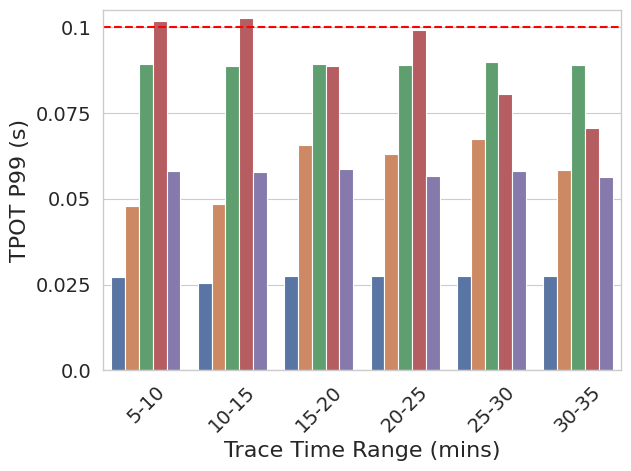

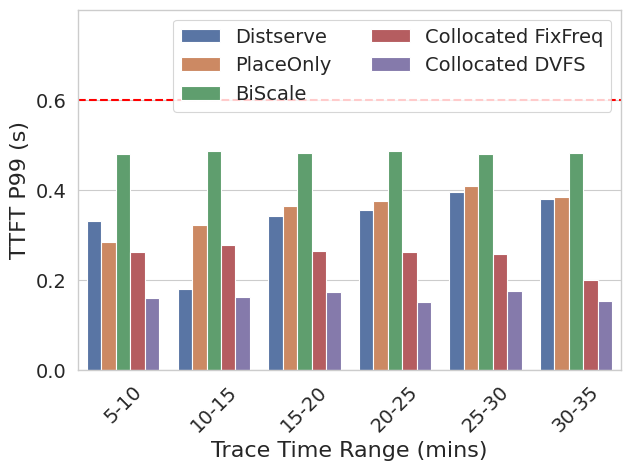

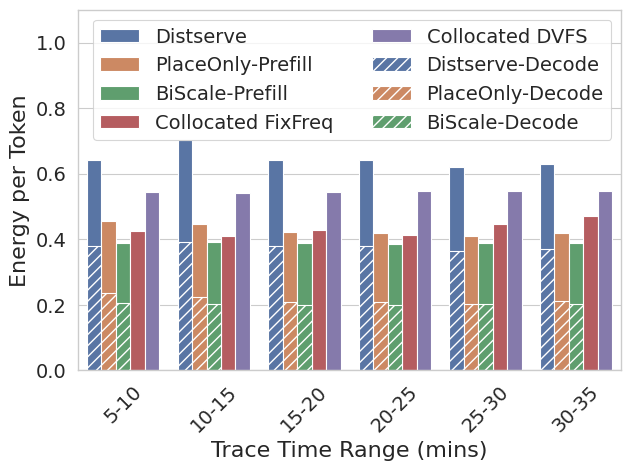

In [97]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/67_percent_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_OLD_P90_6_DVFS', 'OURS_R5_JAN3_OLD_P90_5_DVFS',
    'OURS_R5_JAN3_OLD_P90_4_DVFS', 'OURS_R5_JAN3_OLD_P90_3_DVFS',
    'OURS_R5_JAN3_OLD_P90_2_DVFS', 'OURS_R5_JAN3_OLD_P90_1_DVFS'
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/real/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_OLD_P90_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_OLD_P90_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_OLD_P90_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_OLD_P90_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_OLD_P90_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_OLD_P90_1': 'Distserve 10',
    'OURS_R5_JAN3_OLD_P90_6': 'PlaceOnly 85',
    'OURS_R5_JAN3_OLD_P90_5': 'PlaceOnly 70',
    'OURS_R5_JAN3_OLD_P90_4': 'PlaceOnly 55',
    'OURS_R5_JAN3_OLD_P90_3': 'PlaceOnly 40',
    'OURS_R5_JAN3_OLD_P90_2': 'PlaceOnly 25',
    'OURS_R5_JAN3_OLD_P90_1': 'PlaceOnly 10',
    'OURS_R5_JAN3_OLD_P90_1_DVFS_W': 'BiScale 10',
    'OURS_R5_JAN3_OLD_P90_2_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_OLD_P90_3_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_OLD_P90_4_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_OLD_P90_5_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_OLD_P90_6_DVFS_W': 'BiScale 85',
    'OURS_CHUNK_FEB24_REAL_P67_1_node0': 'Collocated FixFreq 85',
    'OURS_CHUNK_FEB24_REAL_P67_2_node0': 'Collocated FixFreq 70',
    'OURS_CHUNK_FEB24_REAL_P67_3_node0': 'Collocated FixFreq 55',
    'OURS_CHUNK_FEB24_REAL_P67_4_node0': 'Collocated FixFreq 40',
    'OURS_CHUNK_FEB24_REAL_P67_5_node0': 'Collocated FixFreq 25',
    'OURS_CHUNK_FEB24_REAL_P67_6_node0': 'Collocated FixFreq 10',
    'OURS_CHUNK_FEB24_REAL_P67_1_DVFS_node1': 'Collocated DVFS 85',
    'OURS_CHUNK_FEB24_REAL_P67_2_DVFS_node1': 'Collocated DVFS 70',
    'OURS_CHUNK_FEB24_REAL_P67_3_DVFS_node1': 'Collocated DVFS 55',
    'OURS_CHUNK_FEB24_REAL_P67_4_DVFS_node1': 'Collocated DVFS 40',
    'OURS_CHUNK_FEB24_REAL_P67_5_DVFS_node1': 'Collocated DVFS 25',
    'OURS_CHUNK_FEB24_REAL_P67_6_DVFS_node1': 'Collocated DVFS 10'

}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale', 'Collocated FixFreq', 'Collocated DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16)
ax.set_ylabel('TPOT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.105)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14)
ax.legend_.remove()

plt.tight_layout()
plt.savefig("figs/real_67p_trace_tpot.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16)
ax.set_ylabel('TTFT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.8)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14)
ax.legend(title="", fontsize=14, ncol=2)

plt.tight_layout()
plt.savefig("figs/real_67p_trace_ttft.pdf", format="pdf")

############################ energy per token #######################
filtered_handles = []
filtered_labels = []

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

df_results_de = df_results[df_results['decode_energy_per_token'].notnull() & df_results['decode_energy_per_token'] > 0]
ax2 = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results_de, 
    dodge=True,
    hatch='///',
)
# Build custom legend
handles, labels = ax.get_legend_handles_labels()
handles = handles[:-2]
labels = labels[:-2]
labels = ['Distserve',
        'PlaceOnly-Prefill',
        'BiScale-Prefill',
        'Collocated FixFreq',
        'Collocated DVFS',
        'Distserve-Decode',
        'PlaceOnly-Decode',
        'BiScale-Decode']
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16)
ax.set_ylabel('Energy per Token', fontsize=16)
ax.set_ylim(0, 1.1)

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=14)
ax.legend(handles, labels, title="", fontsize=14, ncol=2)
plt.tight_layout()
plt.savefig("figs/real_67p_trace_energy_per_token.pdf", format="pdf")

In [98]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_M'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'PlaceOnly')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results[['expr_dir', 'energy_per_token', 'energy_norm_D', 'energy_norm_M']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_token,energy_norm_D,energy_norm_M
148,PlaceOnly 85,0.420702,33.104501,0.000000
127,PlaceOnly 70,0.409741,33.828273,0.000000
106,PlaceOnly 55,0.419119,34.782083,0.000000
85,PlaceOnly 40,0.420812,34.562176,0.000000
64,PlaceOnly 25,0.448019,36.296240,0.000000
43,PlaceOnly 10,0.455848,28.856378,0.000000
36,Distserve 85,0.628895,0.000000,-49.486888
30,Distserve 70,0.619209,0.000000,-51.121944
24,Distserve 55,0.642644,0.000000,-53.332098
18,Distserve 40,0.643072,0.000000,-52.816817


/tmp/ipykernel_1010699/2062754714.py:92: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_1010699/2062754714.py:117: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


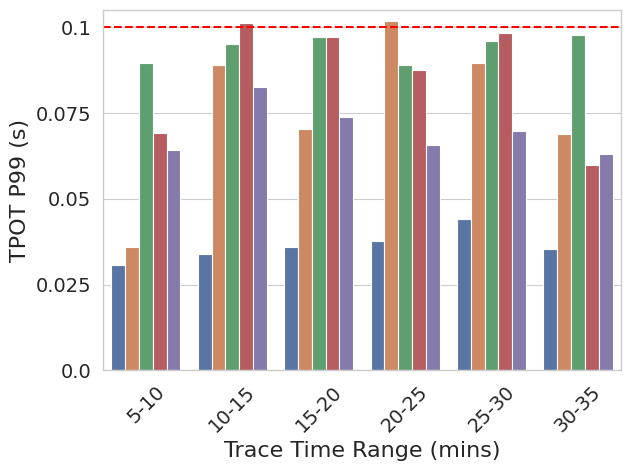

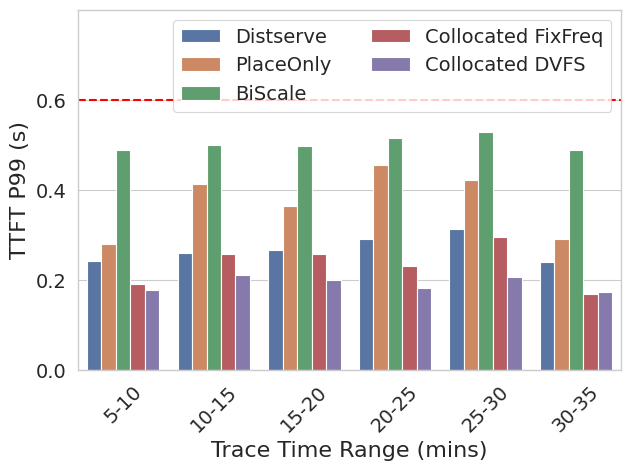

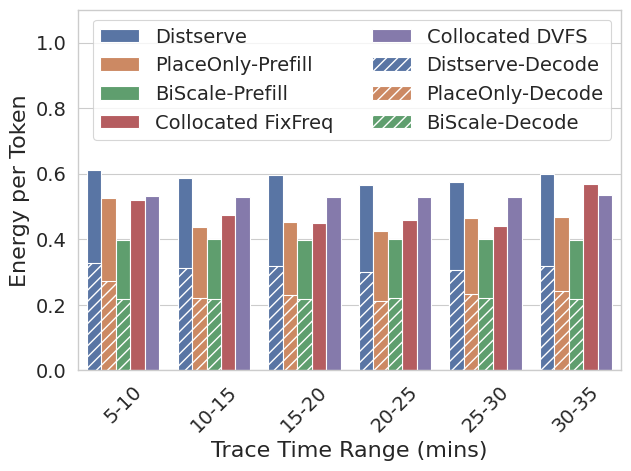

In [99]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/metrics.csv"
df_results_disag = pd.read_csv(path)
df_results_disag = df_results_disag[~df_results_disag['expr_dir'].isin([
    'OURS_R5_JAN3_REAL_P85_6_DVFS', 'OURS_R5_JAN3_REAL_P85_5_DVFS',
    'OURS_R5_JAN3_REAL_P85_4_DVFS', 'OURS_R5_JAN3_REAL_P85_3_DVFS',
    'OURS_R5_JAN3_REAL_P85_2_DVFS', 'OURS_R5_JAN3_REAL_P85_1_DVFS'
])]

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/DVFS/real/profiler_logs_Feb28_chunk_dvfs_other_0/metrics.csv'
df_results_collocated_dvfs = pd.read_csv(path)

path = '/export2/obasit/ClusterLevelServing/vllm_logs/asplos_logs/collocated_logs/ours/profiler_logs_Feb25_chunk_fix_freq_0/real/metrics.csv'
df_results_collocated_fix_freq = pd.read_csv(path)

df_results = pd.concat([df_results_disag, df_results_collocated_dvfs, df_results_collocated_fix_freq])

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P85_6': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P85_5': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P85_4': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P85_3': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P85_2': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P85_1': 'Distserve 10',
    'OURS_R5_JAN3_REAL_P85_6': 'PlaceOnly 85',
    'OURS_R5_JAN3_REAL_P85_5': 'PlaceOnly 70',
    'OURS_R5_JAN3_REAL_P85_4': 'PlaceOnly 55',
    'OURS_R5_JAN3_REAL_P85_3': 'PlaceOnly 40',
    'OURS_R5_JAN3_REAL_P85_2': 'PlaceOnly 25',
    'OURS_R5_JAN3_REAL_P85_1': 'PlaceOnly 10',
    'OURS_R5_JAN3_REAL_P85_6_DVFS_W': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P85_5_DVFS_W': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P85_4_DVFS_W': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P85_3_DVFS_W': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P85_2_DVFS_W': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P85_1_DVFS_W': 'BiScale 10',
    'OURS_CHUNK_FEB24_REAL_P85_1_node0': 'Collocated FixFreq 85',
    'OURS_CHUNK_FEB24_REAL_P85_2_node0': 'Collocated FixFreq 70',
    'OURS_CHUNK_FEB24_REAL_P85_3_node0': 'Collocated FixFreq 55',
    'OURS_CHUNK_FEB24_REAL_P85_4_node0': 'Collocated FixFreq 40',
    'OURS_CHUNK_FEB24_REAL_P85_5_node0': 'Collocated FixFreq 25',
    'OURS_CHUNK_FEB24_REAL_P85_6_node0': 'Collocated FixFreq 10',
    'OURS_CHUNK_FEB24_REAL_P85_1_DVFS_node1': 'Collocated DVFS 85',
    'OURS_CHUNK_FEB24_REAL_P85_2_DVFS_node1': 'Collocated DVFS 70',
    'OURS_CHUNK_FEB24_REAL_P85_3_DVFS_node1': 'Collocated DVFS 55',
    'OURS_CHUNK_FEB24_REAL_P85_4_DVFS_node1': 'Collocated DVFS 40',
    'OURS_CHUNK_FEB24_REAL_P85_5_DVFS_node1': 'Collocated DVFS 25',
    'OURS_CHUNK_FEB24_REAL_P85_6_DVFS_node1': 'Collocated DVFS 10'

}


# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)
df_results = df_results[df_results['expr_dir'].isin(rename_mapping.values())]
df_results = df_results[~df_results['expr_dir'].str.contains('OURS_R5_JAN3_OLD_P90_.*_DVFS', regex=True)]

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale', 'Collocated FixFreq', 'Collocated DVFS'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

####################### TPOT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16)
ax.set_ylabel('TPOT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.105)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14)
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/real_85p_trace_tpot.pdf", format="pdf")

######################## TTFT P99 #######################

sns.set_theme(context="paper", style="whitegrid")
plt.figure(constrained_layout=True)
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16)
ax.set_ylabel('TTFT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.8)
ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14)
ax.legend(title="", fontsize=14, ncol=2)

plt.tight_layout()
plt.savefig("figs/real_85p_trace_ttft.pdf", format="pdf")

############################ energy per token #######################
filtered_handles = []
filtered_labels = []

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

df_results_de = df_results[df_results['decode_energy_per_token'].notnull() & df_results['decode_energy_per_token'] > 0]
ax2 = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results_de, 
    dodge=True,
    hatch='///',
)
# Build custom legend
handles, labels = ax.get_legend_handles_labels()
handles = handles[:-2]
labels = labels[:-2]
labels = ['Distserve',
        'PlaceOnly-Prefill',
        'BiScale-Prefill',
        'Collocated FixFreq',
        'Collocated DVFS',
        'Distserve-Decode',
        'PlaceOnly-Decode',
        'BiScale-Decode']
# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16)
ax.set_ylabel('Energy per Token', fontsize=16)
ax.set_ylim(0, 1.1)

ax.set_xticks([0,1,2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=14)
ax.legend(handles, labels, title="", fontsize=14, ncol=2)
plt.tight_layout()
plt.savefig("figs/real_85p_trace_energy_per_token.pdf", format="pdf")

In [100]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_M'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'PlaceOnly')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results[['expr_dir', 'energy_per_token', 'energy_norm_D', 'energy_norm_M']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_token,energy_norm_D,energy_norm_M
153,PlaceOnly 85,0.467530,21.931246,0.000000
132,PlaceOnly 70,0.465990,18.980667,0.000000
111,PlaceOnly 55,0.426457,24.720725,0.000000
90,PlaceOnly 40,0.452743,23.970636,0.000000
69,PlaceOnly 25,0.438875,25.349210,0.000000
48,PlaceOnly 10,0.525190,14.185519,0.000000
41,Distserve 85,0.598869,0.000000,-28.092221
34,Distserve 70,0.575159,0.000000,-23.427331
27,Distserve 55,0.566500,0.000000,-32.838687
20,Distserve 40,0.595485,0.000000,-31.528130
